device: cuda
checkpoint exists: True


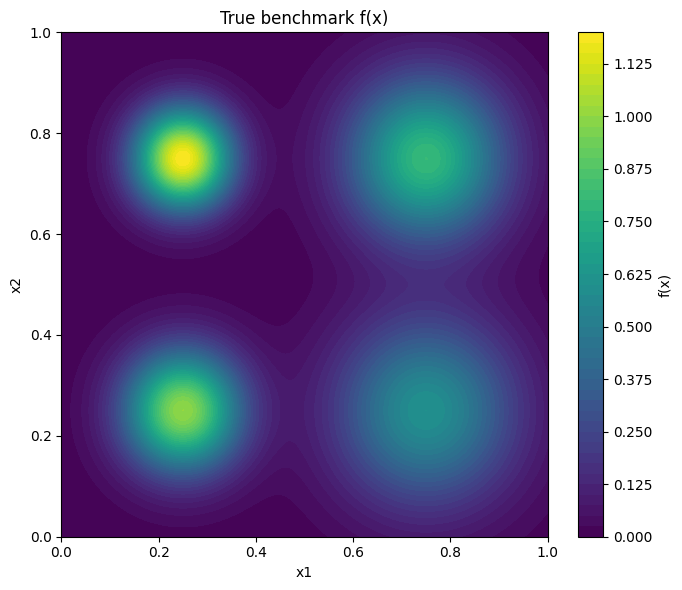

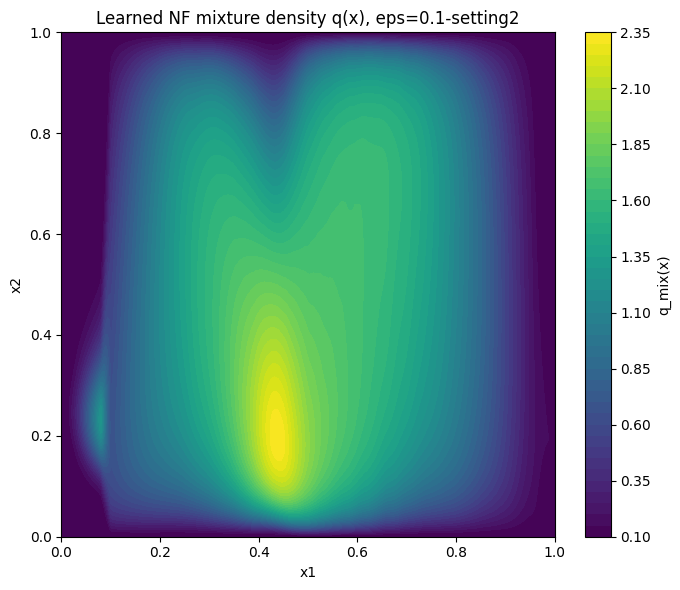

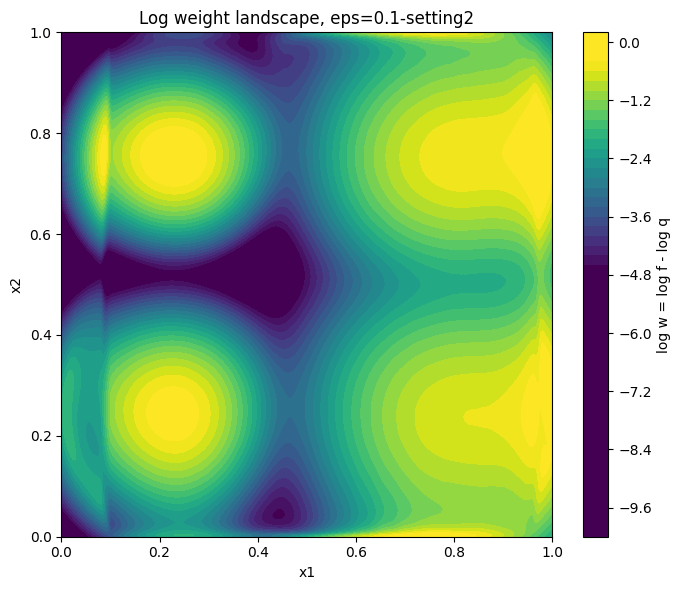

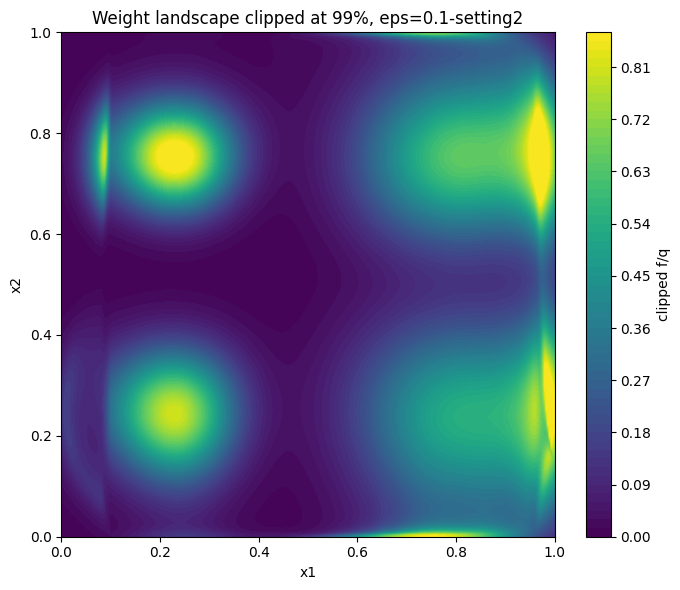

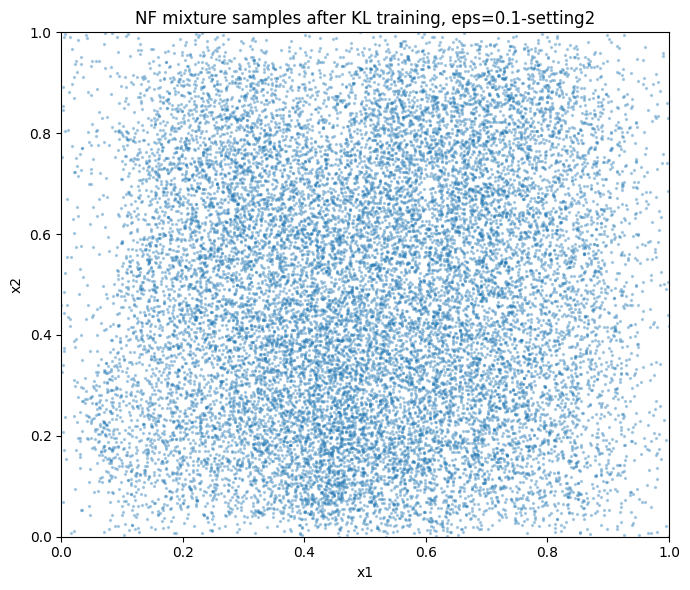

Saved all diagnostic plots to: /direct/usatlas+u/zhaozhong/nf_integrator/results/plots/diagnostics


In [13]:
import os
import sys
import torch
import matplotlib.pyplot as plt

# =====================================
# paths
# =====================================

REPO = "/direct/usatlas+u/zhaozhong/nf_integrator"
sys.path.insert(0, REPO)

from benchmarks.registry import get_benchmark
from nf.cube_flow import CubeRealNVP


# =====================================
# settings
# =====================================

DIM = 2
EPS = 0.10
BENCHMARK = "easy_four_gaussian"

CKPT_PATH = f"{REPO}/results/checkpoints/nf_A_kl_floor010-setting2.pt"
SAVE_DIR = f"{REPO}/results/plots/diagnostics"
os.makedirs(SAVE_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("device:", device)
print("checkpoint exists:", os.path.exists(CKPT_PATH))

benchmark_fn = get_benchmark(BENCHMARK)


# =====================================
# load trained NF
# =====================================

model = CubeRealNVP(
    dim=DIM,
    n_blocks=20,
    hidden=256,
    eps_mix=EPS,
).to(device)

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()


# =====================================
# build grid
# =====================================

n_grid = 300

x1 = torch.linspace(0, 1, n_grid, device=device)
x2 = torch.linspace(0, 1, n_grid, device=device)

X1, X2 = torch.meshgrid(x1, x2)

X = torch.stack(
    [X1.reshape(-1), X2.reshape(-1)],
    dim=1,
)


# =====================================
# evaluate
# =====================================

with torch.no_grad():
    f_vals = benchmark_fn(X)
    log_q = model.log_prob(X)
    q_vals = torch.exp(log_q)
    log_w = torch.log(f_vals + 1e-12) - log_q
    w_vals = torch.exp(log_w)

F = f_vals.reshape(n_grid, n_grid).detach().cpu()
Q = q_vals.reshape(n_grid, n_grid).detach().cpu()
LOGW = log_w.reshape(n_grid, n_grid).detach().cpu()
W = w_vals.reshape(n_grid, n_grid).detach().cpu()

X1_cpu = X1.detach().cpu()
X2_cpu = X2.detach().cpu()


# =====================================
# Plot 1: true benchmark
# =====================================

plt.figure(figsize=(7, 6))
plt.contourf(X1_cpu, X2_cpu, F, levels=50)
plt.colorbar(label="f(x)")
plt.title("True benchmark f(x)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/true_benchmark_{BENCHMARK}.png", dpi=300)
plt.show()


# =====================================
# Plot 2: learned NF density
# =====================================

plt.figure(figsize=(7, 6))
plt.contourf(X1_cpu, X2_cpu, Q, levels=50)
plt.colorbar(label="q_mix(x)")
plt.title(f"Learned NF mixture density q(x), eps={EPS}-setting2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/learned_nf_density_eps{EPS}-setting2.png", dpi=300)
plt.show()


# =====================================
# Plot 3: log weight landscape
# =====================================

vmin = torch.quantile(LOGW.flatten(), 0.05).item()
vmax = torch.quantile(LOGW.flatten(), 0.95).item()

plt.figure(figsize=(7, 6))
plt.contourf(X1_cpu, X2_cpu, LOGW, levels=60, vmin=vmin, vmax=vmax)
plt.colorbar(label="log w = log f - log q")
plt.title(f"Log weight landscape, eps={EPS}-setting2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/log_weight_eps{EPS}-setting2.png", dpi=300)
plt.show()


# =====================================
# Plot 4: clipped raw weight landscape
# =====================================

w_vmax = torch.quantile(W.flatten(), 0.99).item()
W_clip = torch.clamp(W, max=w_vmax)

plt.figure(figsize=(7, 6))
plt.contourf(X1_cpu, X2_cpu, W_clip, levels=60)
plt.colorbar(label="clipped f/q")
plt.title(f"Weight landscape clipped at 99%, eps={EPS}-setting2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/weight_clipped_eps{EPS}-setting2.png", dpi=300)
plt.show()


# =====================================
# Plot 5: NF samples
# =====================================

with torch.no_grad():
    samples = model.sample(20000, device=device).detach().cpu()

plt.figure(figsize=(7, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title(f"NF mixture samples after KL training, eps={EPS}-setting2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/nf_samples_eps{EPS}-setting2.png", dpi=300)
plt.show()

print(f"Saved all diagnostic plots to: {SAVE_DIR}")